In [1]:
%pylab inline

import jax
import jax.numpy as jnp
import tensorflow_probability as tfp; tfp = tfp.substrates.jax
tfd = tfp.distributions
tfb = tfp.bijectors

from jaxlie import SO3
from so3dm.distributions.isotropic_gaussian import IsotropicGaussianSO3
from so3dm.plotting import visualize_so3_probabilities

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## Create test distribution

In [2]:
def sample_checkerboard(batch_size, size=np.pi):
    x1 = np.random.rand(batch_size) * size - size/2
    x2_ = np.random.rand(batch_size) - np.random.randint(0, 2, batch_size) * 2
    x2 = x2_ + (np.floor(x1) % 2)
    data = np.concatenate([x1[:, None], x2[:, None]], 1) * size/2
    Rs = jax.jit(jax.vmap(lambda x: SO3.from_rpy_radians(pitch=x[0]/2, yaw=x[1], roll=0).as_matrix()))(data)
    return Rs

In [3]:
# Create a checkerboard grid
Rs = sample_checkerboard(1024)

/home/francois/repo/SO3DiffusionModels/so3dm/plotting.py:98: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([r'90$\degree$', None,


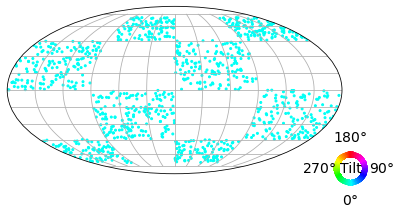

In [4]:
visualize_so3_probabilities(
    Rs,
    0.001);

## Create the noisy dataset

In [141]:
import tensorflow_datasets as tfds

In [142]:
@jax.jit
@jax.vmap
def sample(R, scale, seed):
    q = IsotropicGaussianSO3(SO3.identity(), scale).sample(seed=seed)
    Y = (SO3.from_matrix(R) @ SO3(q))
    return {'x': SO3.from_matrix(R).wxyz, 'y': Y.wxyz, 'ylog': Y.log(), 'u': q, 'ulog':SO3(q).log(), 's':scale}

def get_batch(batch_size, noise_dist_std, seed):
    # Sample from the target distribution
    Rs = sample_checkerboard(batch_size)
    
    # Sample standard deviation of noise corruption
    s = noise_dist_std * jnp.abs(randn(batch_size)) + 1e-2
    
    # Sample random rotations
    return sample(Rs, s, jax.random.split(seed, batch_size))

In [261]:
batch = get_batch(2048, 0.1, jax.random.PRNGKey(0))

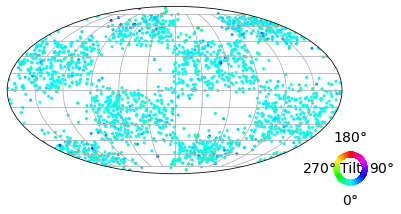

In [262]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(batch['y']),
    0.001);

In [263]:
from so3dm.distributions.isotropic_gaussian import _isotropic_gaussian_so3_small
import haiku as hk
import optax

# Create a random sequence
rng_seq = hk.PRNGSequence(42)

In [264]:
def forward(x,t):
    mlp = hk.nets.MLP([128, 128, 128], activation=jax.nn.leaky_relu)
    return hk.Linear(3)(mlp(jnp.concatenate([x,t],axis=-1)))

model = hk.without_apply_rng(hk.transform(forward))
params = model.init(jax.random.PRNGKey(0), jnp.zeros([1,4]),jnp.zeros([1,1]),)

In [265]:
optimizer = optax.adam(learning_rate=2e-4)
rng_seq = hk.PRNGSequence(42)

In [266]:
opt_state = optimizer.init(params)

In [267]:
def loss_fn(params, rng_key, batch):
    s = batch['s'].reshape([-1,1])
    score = model.apply(params, batch['y'], s)
    
    @jax.vmap
    def get_angles(u, x):
        axis_angle = (SO3(u).inverse() @ SO3.exp(x)).log()
        return jnp.linalg.norm(axis_angle, axis=-1)
    
    angles = get_angles(batch['u'], score)
    
    loss = _isotropic_gaussian_so3_small(angles, s/jnp.sqrt(2))
    
    return jnp.mean(loss)

In [268]:
@jax.jit
def update(params, rng_key, opt_state, batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng_key, batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, new_opt_state

losses = []

In [269]:
from flax.metrics import tensorboard
summary_writer = tensorboard.SummaryWriter('test')

In [270]:
for step in range(100):
    batch = get_batch(128, 0.1, seed=next(rng_seq))
    loss, params, opt_state = update(params, next(rng_seq), opt_state, batch)
    losses.append(loss)
    if isnan(loss):
        break
    summary_writer.scalar('train_loss', loss, step)

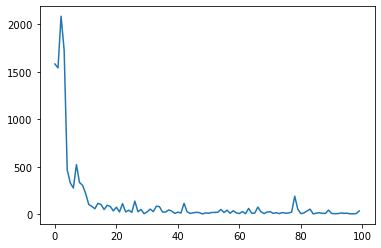

In [271]:
plot(losses)

In [293]:
# Try to sample with the trained model
points = sample_checkerboard(1024)
points = sample(points, 0.2*jnp.ones(1024), jax.random.split(jax.random.PRNGKey(0),1024))

@jax.jit
def dynamics(t, x):
  return - 0.5*model.apply(params,x,jnp.ones([1024,1])*jnp.sqrt(t)) #* (jnp.sqrt(t)/jnp.sqrt(2))**2

In [294]:
y = points['y']
ts = jnp.linspace(0.2,0.01, 128)
h = (ts[1] - ts[0])
ys = [y]

# This is a simple implementation of a forward Euler integration scheme
for t in ts:
    dy = dynamics(t, y)
    y = jax.vmap(lambda u,v: (SO3(v) @ SO3.exp(u) ).wxyz)(h*dy,y)
    ys.append(y*1)

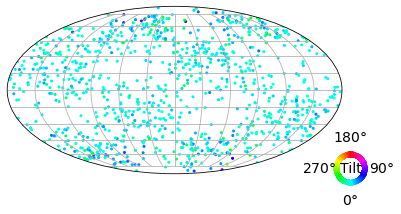

In [296]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(ys[0]),
    0.001);

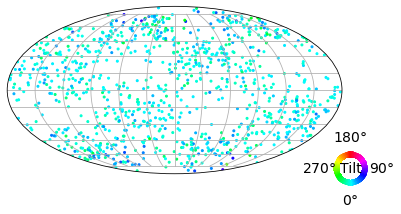

In [297]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(ys[-1]),
    0.001);